In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
from collections import Counter

In [13]:
print("Step 1: Loading Sheets from Excel...")

file_name = 'Global Superstore.xlsx'

try:
    orders = pd.read_excel(file_name, sheet_name='Orders')
    returns = pd.read_excel(file_name, sheet_name='Returns')
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found.")
    print("Please ensure the Excel file is in the same directory as this script.")

Step 1: Loading Sheets from Excel...


In [14]:
print("Step 2: Cleaning and Merging Data...")

returns_clean = returns[['Order ID', 'Returned']].drop_duplicates()
data = pd.merge(orders, returns_clean, on='Order ID', how='left')
data['Returned'] = data['Returned'].fillna('No').apply(lambda x: 1 if x == 'Yes' else 0)

Step 2: Cleaning and Merging Data...


In [15]:
print("Step 3: Engineering New Features...")

data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])
data['Processing_Time'] = (data['Ship Date'] - data['Order Date']).dt.days
data['Profit_Margin'] = data['Profit'] / (data['Sales'] + 0.001)

features = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category',
            'Sales', 'Quantity', 'Discount', 'Shipping Cost',
            'Processing_Time', 'Profit_Margin']

X = data[features].copy()
y = data['Returned'].copy()

Step 3: Engineering New Features...


In [16]:
print("Step 4: Encoding Categorical Features...")

for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Step 4: Encoding Categorical Features...


In [17]:
print("Step 5: Balancing Classes with SMOTE...")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {Counter(y_train)}")
print(f"After SMOTE:  {Counter(y_train_resampled)}")

Step 5: Balancing Classes with SMOTE...
Before SMOTE: Counter({0: 34349, 1: 1554})
After SMOTE:  Counter({0: 34349, 1: 34349})


In [18]:
print("Step 6: Training Random Forest Classifier...")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)

Step 6: Training Random Forest Classifier...


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
print("Step 7: Evaluating Model with Custom Threshold...")

y_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
threshold = 0.35
y_pred_custom = (y_probs >= threshold).astype(int)

print(f"\n--- Final Report (Threshold = {threshold}) ---")
print(classification_report(y_test, y_pred_custom))

precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)
print(f"Final Model PR-AUC Score: {pr_auc:.3f}")

Step 7: Evaluating Model with Custom Threshold...

--- Final Report (Threshold = 0.35) ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14721
           1       0.06      0.02      0.03       666

    accuracy                           0.94     15387
   macro avg       0.51      0.50      0.50     15387
weighted avg       0.92      0.94      0.93     15387

Final Model PR-AUC Score: 0.052


Step 5: Balancing Classes with SMOTE...
Before SMOTE: Counter({0: 34349, 1: 1554})
After SMOTE:  Counter({0: 34349, 1: 34349})


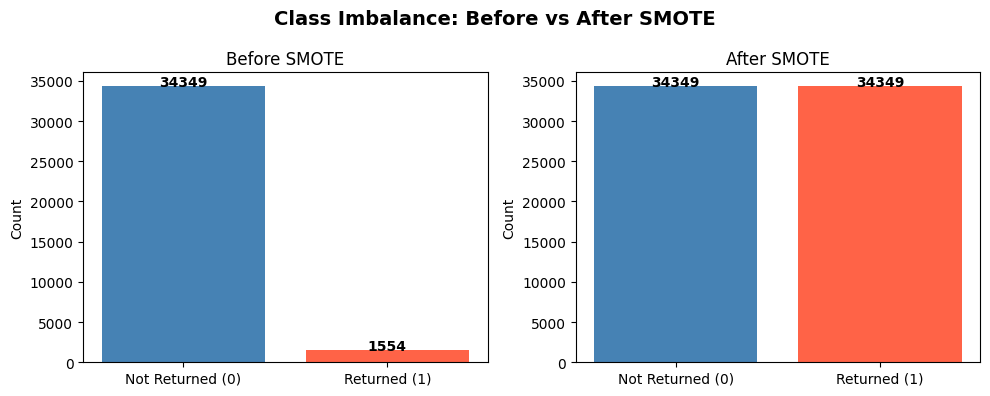

In [20]:
print("Step 5: Balancing Classes with SMOTE...")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

before = Counter(y_train)
after = Counter(y_train_resampled)
print(f"Before SMOTE: {before}")
print(f"After SMOTE:  {after}")

# --- Graph: Class Imbalance Before vs After SMOTE ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Not Returned (0)', 'Returned (1)'], [before[0], before[1]], color=['steelblue', 'tomato'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate([before[0], before[1]]):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].bar(['Not Returned (0)', 'Returned (1)'], [after[0], after[1]], color=['steelblue', 'tomato'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')
for i, v in enumerate([after[0], after[1]]):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Imbalance: Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Step 6: Training Random Forest Classifier...


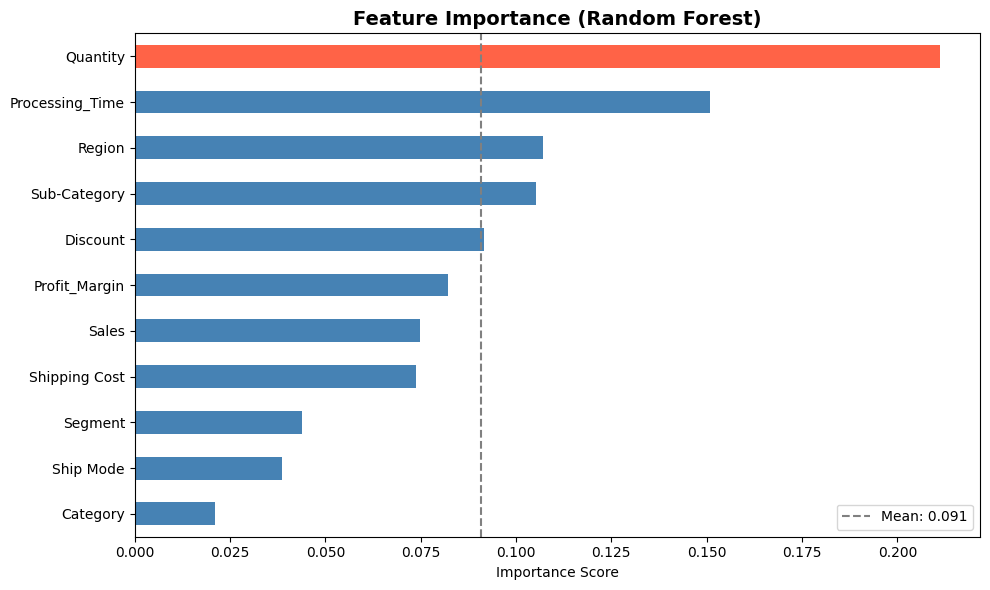

In [21]:
print("Step 6: Training Random Forest Classifier...")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)

# --- Graph: Feature Importance ---
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['tomato' if v == importances.max() else 'steelblue' for v in importances]
importances.plot(kind='barh', color=colors)
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(importances.mean(), color='gray', linestyle='--', label=f'Mean: {importances.mean():.3f}')
plt.legend()
plt.tight_layout()
plt.show()

Step 7: Evaluating Model with Custom Threshold...

--- Final Report (Threshold = 0.35) ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14721
           1       0.06      0.02      0.03       666

    accuracy                           0.94     15387
   macro avg       0.51      0.50      0.50     15387
weighted avg       0.92      0.94      0.93     15387

Final Model PR-AUC Score: 0.052


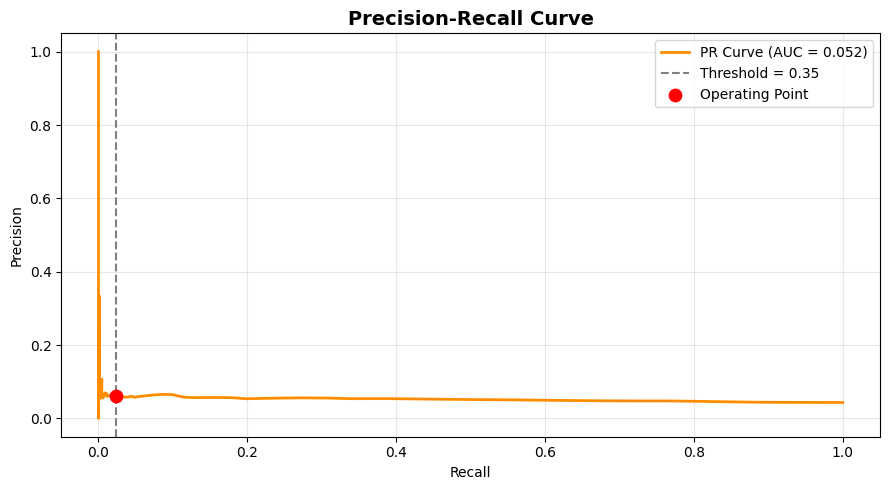

In [22]:
print("Step 7: Evaluating Model with Custom Threshold...")

y_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
threshold = 0.35
y_pred_custom = (y_probs >= threshold).astype(int)

print(f"\n--- Final Report (Threshold = {threshold}) ---")
print(classification_report(y_test, y_pred_custom))

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)
print(f"Final Model PR-AUC Score: {pr_auc:.3f}")

# --- Graph: Precision-Recall Curve ---
plt.figure(figsize=(9, 5))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.axvline(x=recall[np.argmin(np.abs(thresholds - threshold))], 
            color='gray', linestyle='--', label=f'Threshold = {threshold}')
plt.scatter(recall[np.argmin(np.abs(thresholds - threshold))], 
            precision[np.argmin(np.abs(thresholds - threshold))], 
            color='red', zorder=5, s=80, label='Operating Point')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()